In [21]:
import json
from pathlib import Path

import csv

from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------
# Paths
# --------------------------------------------------

In [2]:
PROJECT_ROOT = Path.cwd()

TRAIN_IMAGE_DIR = PROJECT_ROOT / "data" / "stenosis" / "train" / "images"
TRAIN_ANNOTATION = PROJECT_ROOT / "data" / "stenosis" / "train" / "annotations" / "train.json"
print(TRAIN_IMAGE_DIR)
print(TRAIN_ANNOTATION)

C:\Users\homsokhim\PycharmProjects\Health_analysis\data\stenosis\train\images
C:\Users\homsokhim\PycharmProjects\Health_analysis\data\stenosis\train\annotations\train.json


# --------------------------------------------------
# Check the dataset
# --------------------------------------------------

In [3]:
print("Images:", len(list(TRAIN_IMAGE_DIR.glob("*.png"))))
print("Annotation exists:", TRAIN_ANNOTATION.exists())

Images: 1000
Annotation exists: True


# --------------------------------------------------
# Load train annotation JSON
# --------------------------------------------------

In [4]:
with open(TRAIN_ANNOTATION, "r") as f:
    data = json.load(f)

print(data.keys())

dict_keys(['images', 'annotations', 'categories'])


In [5]:
print("Images:", len(data["images"]))
print("Categories:", len(data["categories"]))
print("Annotations:", len(data["annotations"]))

Images: 1000
Categories: 26
Annotations: 1625


# --------------------------------------------------
# Look at one annotation
# --------------------------------------------------

In [6]:
stenosis_annotations = [
    ann
    for ann in data["annotations"]
    if ann["category_id"] == 26
]

annotation = stenosis_annotations[0]

print("Annotation ID:", annotation["id"])
print("Image ID:", annotation["image_id"])
print("Category ID:", annotation["category_id"])
print("Bounding box:", annotation["bbox"])

Annotation ID: 1
Image ID: 676
Category ID: 26
Bounding box: [278.0, 245.12, 42.75, 54.13]


In [7]:
# Find the image information
image_info = next(
    img
    for img in data["images"]
    if img["id"] == annotation["image_id"]
)

print(image_info)

{'id': 676, 'width': 512, 'height': 512, 'file_name': '676.png', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}


In [16]:
IMAGE_DIR = "data/stenosis/train/images/"
image_path = IMAGE_DIR +  image_info["file_name"]

print("Image path:")
print(image_path)

Image path:
data/stenosis/train/images/676.png


Image size: (512, 512)


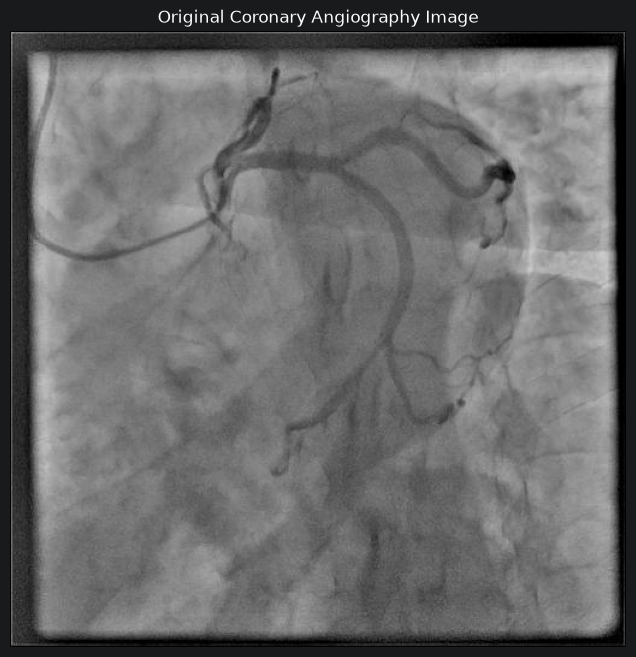

In [20]:
image = Image.open(image_path).convert("RGB")

print("Image size:", image.size)

plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Original Coronary Angiography Image")
plt.show()

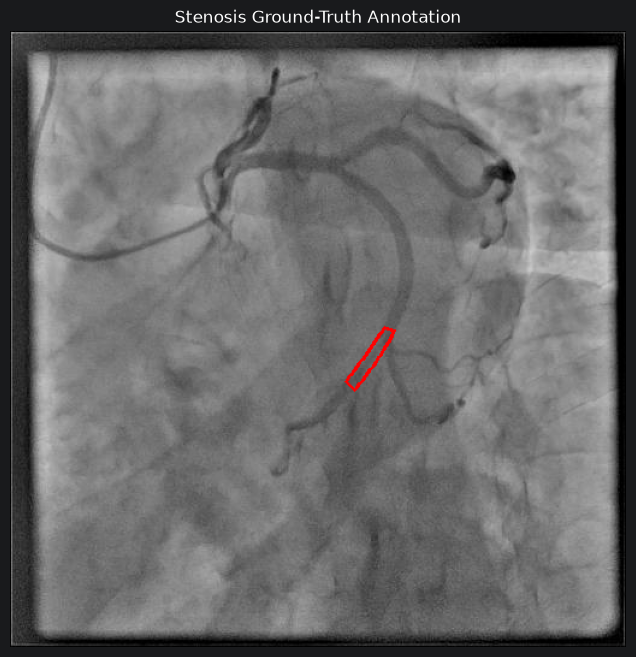

In [22]:
# Create a copy of the image
image_with_mask = image.copy()

draw = ImageDraw.Draw(image_with_mask)

# Get segmentation polygons
segmentation = annotation["segmentation"]

for polygon in segmentation:
    # Convert:
    # [x1, y1, x2, y2, ...]
    # into:
    # [(x1,y1), (x2,y2), ...]
    points = [
        (polygon[i], polygon[i + 1])
        for i in range(0, len(polygon), 2)
    ]

    # Draw polygon outline
    draw.polygon(
        points,
        outline="red",
        width=3
    )

plt.figure(figsize=(10, 8))
plt.imshow(image_with_mask)
plt.axis("off")
plt.title("Stenosis Ground-Truth Annotation")
plt.show()

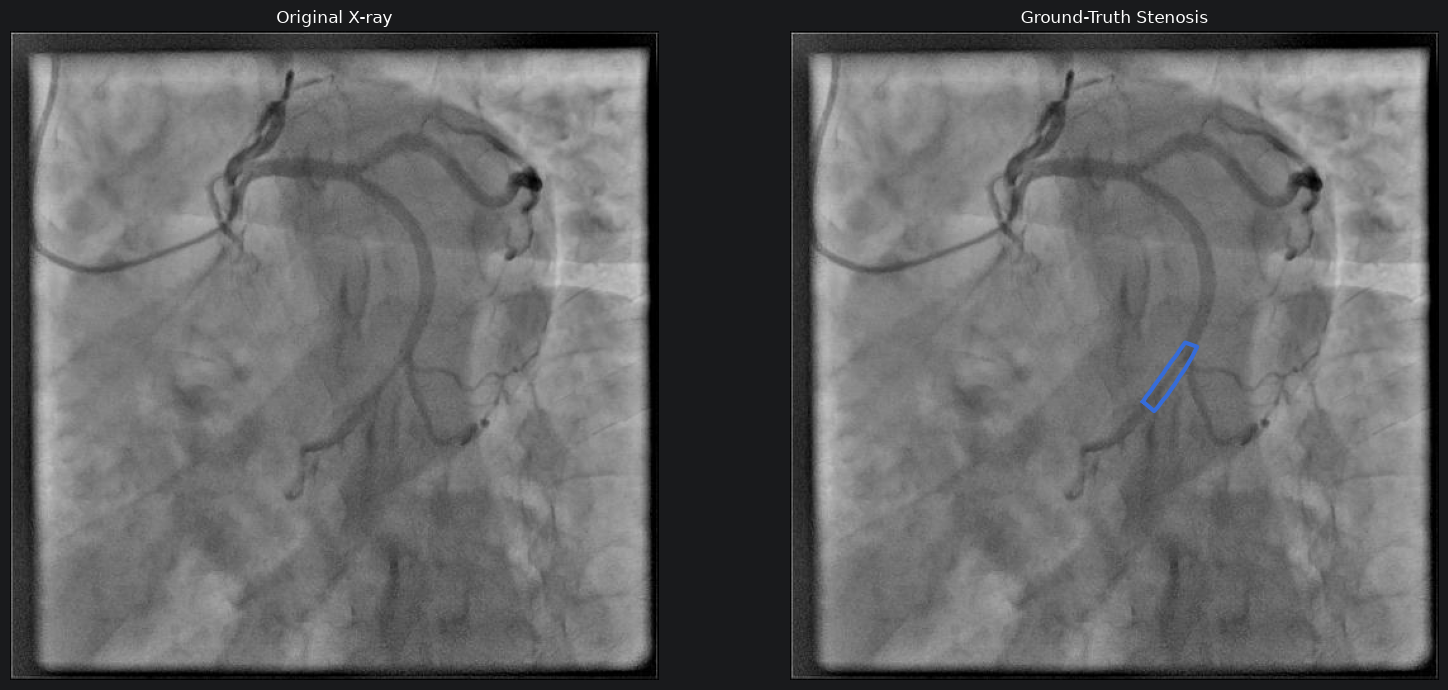

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# -------------------------
# Original image
# -------------------------

axes[0].imshow(image)
axes[0].set_title("Original X-ray")
axes[0].axis("off")


# -------------------------
# Ground truth
# -------------------------

axes[1].imshow(image)

for polygon in annotation["segmentation"]:
    points = [
        (polygon[i], polygon[i + 1])
        for i in range(0, len(polygon), 2)
    ]

    xs = [p[0] for p in points]
    ys = [p[1] for p in points]

    axes[1].plot(xs + [xs[0]], ys + [ys[0]], linewidth=3)

axes[1].set_title("Ground-Truth Stenosis")
axes[1].axis("off")

plt.tight_layout()
plt.show()